In [ ]:
# ============================================================
# LAB 1: Impact of Padding and Stride in CNNs
# Objective:
# Understand how padding and stride influence:
# - Spatial dimensions
# - Feature extraction
# - Number of parameters
# - Training speed
# - Inference speed
# - Accuracy
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.19.0


Loading MNIST Dataset

In [ ]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)

print("Training shape:", x_train.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28, 1)


using CNN Builder Function

In [ ]:
def build_cnn(padding='same', strides=(1,1)):

    model = keras.Sequential([
        layers.Input(shape=(28,28,1)),

        layers.Conv2D(32, (3,3),
                      padding=padding,
                      strides=strides,
                      activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3),
                      padding=padding,
                      strides=strides,
                      activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model


In [ ]:
experiments = [
    {"name": "Same padding, stride 1",  "padding": "same",  "strides": (1,1)},
    {"name": "Valid padding, stride 1", "padding": "valid", "strides": (1,1)},
    {"name": "Same padding, stride 2",  "padding": "same",  "strides": (2,2)},
    {"name": "Valid padding, stride 2", "padding": "valid", "strides": (2,2)},
    {"name": "Same padding, stride 3",  "padding": "same",  "strides": (3,3)},
]


Running Experiment

In [ ]:
results = []

for exp in experiments:

    print("\n" + "="*60)
    print("Running:", exp["name"])

    model = build_cnn(exp["padding"], exp["strides"])
    model.summary()

    # Training time
    start_train = time.time()

    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    train_time = time.time() - start_train

    # Evaluation
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    # Inference time
    start_inf = time.time()
    model.predict(x_test[:1000], verbose=0)
    inference_time = time.time() - start_inf

    results.append({
        "Config": exp["name"],
        "Padding": exp["padding"],
        "Stride": exp["strides"],
        "Parameters": model.count_params(),
        "Train Time (s)": round(train_time,2),
        "Inference Time (s)": round(inference_time,4),
        "Test Accuracy": round(test_acc,4)
    })



Running: Same padding, stride 1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 10, 10, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 2, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,426 (111.04 KB)

 Trainable params: 28,426 (111.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6264 - loss: 1.1998 - val_accuracy: 0.9253 - val_loss: 0.2417
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9062 - loss: 0.3037 - val_accuracy: 0.9487 - val_loss: 0.1653
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9321 - loss: 0.2201 - val_accuracy: 0.9600 - val_loss: 0.1283
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9449 - loss: 0.1761 - val_accuracy: 0.9660 - val_loss: 0.1125
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9524 - loss: 0.1547 - val_accuracy: 0.9678 - val_loss: 0.1031


Display Result Talblel

In [ ]:
df = pd.DataFrame(results)
df


,Config,Padding,Stride,Parameters,Train Time (s),Inference Time (s),Test Accuracy
0,"Same padding, stride 1",same,"(1, 1)",421642,19.61,0.8493,0.9907
1,"Valid padding, stride 1",valid,"(1, 1)",225034,16.75,0.7726,0.9908
2,"Same padding, stride 2",same,"(2, 2)",53002,13.75,0.7399,0.9836
3,"Valid padding, stride 2",valid,"(2, 2)",28426,13.98,0.6692,0.9705
4,"Same padding, stride 3",same,"(3, 3)",28426,14.91,0.6779,0.9613


Visulizaing Feature map

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


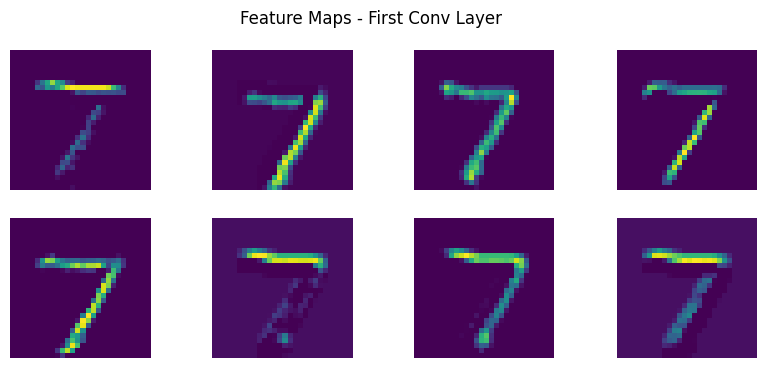

In [ ]:
# Take best model (usually same padding, stride 1)
best_model = build_cnn('same',(1,1))
# Explicitly build the model before fitting or extracting layers
best_model.build(input_shape=(None, 28, 28, 1)) # None for batch size

best_model.fit(x_train, y_train, epochs=3, batch_size=128, verbose=0)

# Extract first conv layer output
layer_output = keras.Model(
    inputs=best_model.inputs, # Use .inputs (plural) which is a list [input_tensor]
    outputs=best_model.layers[0].output
)

sample = x_test[:1]
feature_maps = layer_output.predict(sample)

plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.axis("off")

plt.suptitle("Feature Maps - First Conv Layer")
plt.show()

In [ ]:
###### Using differnet digits

Total 7s in training: 6265.0


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 420,481 (1.60 MB)

 Trainable params: 420,481 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9618 - loss: 0.1039 - val_accuracy: 0.9955 - val_loss: 0.0141
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9936 - loss: 0.0200 - val_accuracy: 0.9975 - val_loss: 0.0082
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9955 - loss: 0.0136 - val_accuracy: 0.9977 - val_loss: 0.0082
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9960 - loss: 0.0111 - val_accuracy: 0.9982 - val_loss: 0.0062
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9970 - loss: 0.0089 - val_accuracy: 0.9988 - val_loss: 0.0056
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9971 - loss: 0.0092
Test Accuracy: 0.9973000288009644


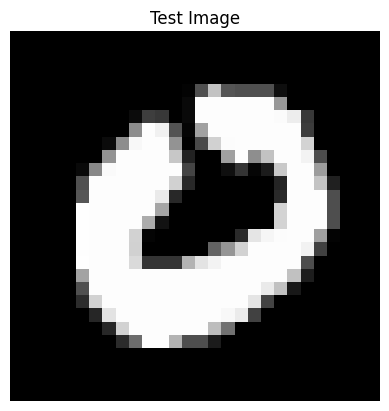

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
Predicted Probability of 7: 2.0967093e-09
Model says: Not 7
Actual Label: 0


In [ ]:
# ==========================================================
# Digit 7 vs Not 7 Classification (Binary CNN)
# ==========================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

# 2️⃣ Convert labels to binary (7 vs not 7)
digit = 7

y_train_binary = (y_train == digit).astype(np.float32)
y_test_binary  = (y_test == digit).astype(np.float32)

print("Total 7s in training:", np.sum(y_train_binary))

# 3️⃣ Build CNN
model = keras.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')   # Binary output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 4️⃣ Train
model.fit(
    x_train, y_train_binary,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

# 5️⃣ Evaluate
loss, acc = model.evaluate(x_test, y_test_binary)
print("Test Accuracy:", acc)

# 6️⃣ Test Prediction
index = 25

plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title("Test Image")
plt.axis("off")
plt.show()

prediction = model.predict(x_test[index:index+1])
print("Predicted Probability of 7:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Model says: It is 7")
else:
    print("Model says: Not 7")

print("Actual Label:", y_test[index])


Multi digit classification

In [ ]:
# ==========================================================
# MNIST Multi-Digit Classification (0–9)
# ==========================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

# One-hot encode labels (10 classes)
y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)

print("Training Shape:", x_train.shape)


Training Shape: (60000, 28, 28, 1)


In [ ]:
model = keras.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')  # 10 digits
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8324 - loss: 0.5566 - val_accuracy: 0.9858 - val_loss: 0.0522
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9751 - loss: 0.0787 - val_accuracy: 0.9868 - val_loss: 0.0444
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9847 - loss: 0.0503 - val_accuracy: 0.9883 - val_loss: 0.0413
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9873 - loss: 0.0389 - val_accuracy: 0.9890 - val_loss: 0.0356
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9897 - loss: 0.0332 - val_accuracy: 0.9902 - val_loss: 0.0341


In [ ]:
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9884 - loss: 0.0289
Test Accuracy: 0.9908000230789185


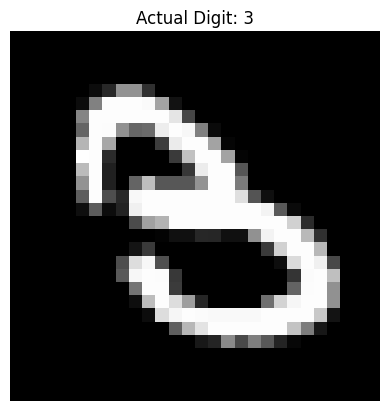

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted Digit: 8


In [ ]:
# Choose which digit you want to test
digit_to_test = 3
# Find index of that digit in test set
indices = np.where(np.argmax(y_test, axis=1) == digit_to_test)[0]

# Pick first example
index = indices[0]

plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title("Actual Digit: " + str(digit_to_test))
plt.axis("off")
plt.show()

# Predict
prediction = model.predict(x_test[index:index+1])
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)
